In [2]:
from typing import List, Tuple
from dataclasses import dataclass

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

from dataUtils import pages_with_annotations
from transformers import BertModel, BertConfig
from transformers import AutoModel, AutoTokenizer

c:\main\GitHub\documentReviewSystem\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
EMBEDDING_MODEL_NAME = 'Snowflake/snowflake-arctic-embed-l-v2.0'
TOKENIZER = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
EMBD_MODEL = AutoModel.from_pretrained(EMBEDDING_MODEL_NAME)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 3492.34it/s]


In [4]:
vocab_size = TOKENIZER.get_vocab()
print(f"Tokenizer vocabulary size: {len(vocab_size)}")

Tokenizer vocabulary size: 250002


In [5]:
class NerDataset(Dataset):
    def __init__(self, data: List, tokenizer: AutoTokenizer, embedding_model: AutoModel):
        self.data = [tup for tup in data if len(tup[1]) != 0]
        self.tokenizer = tokenizer
        self.embedding_model = embedding_model
        self.sequence_length = None
    
    def __len__(self):
        return len(self.data)
    
    def get_max_length(self):
        if self.sequence_length is not None:
            return self.sequence_length
        else:
            max_len = 0
            for data_unit in self.data:
                tokenized_text = self.tokenizer(data_unit[0], return_tensors="pt")["input_ids"].flatten()
                max_len = max(max_len, len(tokenized_text))
            self.sequence_length = max_len
            return max_len
    
    def __getitem__(self, idx):
        data_unit = self.data[idx]
        entity_patterns = [data_unit[0][tup[0]: tup[1]] for tup in data_unit[1]]
        # Here we need to calculate the maximum length so that we pad everything to appropriate size
        tokenized_text = self.tokenizer(data_unit[0], padding="max_length", max_length=self.get_max_length(),
                                        truncation=True, return_tensors='pt')["input_ids"].squeeze(dim=0)
        tokenized_entities = []
        for entity_pattern in entity_patterns:
            tokenized_entity = self.tokenizer(entity_pattern, return_tensors='pt',
                                              add_special_tokens=False)["input_ids"]
            tokenized_entities.append(tokenized_entity.flatten())
        # Find and label the patterns of the sequence
        label_tensor = torch.zeros(tokenized_text.shape, dtype = torch.long)
        for entity in tokenized_entities:
            unfolded_text = tokenized_text.unfold(0, len(entity), 1)
            row_matches = (unfolded_text == entity).all(dim = 1)
            start_ind = torch.nonzero(row_matches, as_tuple = True)[0]
            if len(start_ind):
                unfolded_text = tokenized_text.unfold(0, len(entity)-1, 1)
                row_matches = (unfolded_text == entity[1:]).all(dim = 1)
                start_ind = torch.nonzero(row_matches, as_tuple = True)[0] - 1
            label_tensor[start_ind] = torch.tensor(2, dtype=torch.long)
            for forward_ind in range(1, len(entity)):
                label_tensor[start_ind + forward_ind] = 1
        return tokenized_text, label_tensor

In [6]:
# Different types of RNNs, biRNNs, and multi-layered RNNs 
class NERModelElman(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int,
                 embedding_model: AutoTokenizer, num_layers: int = 2, num_tags: int = 3):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier = nn.Linear(hidden_dim, num_tags)
        self.rnn = nn.RNN(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers)

    def forward(self, x: torch.tensor) -> torch.tensor:
        """x is tensor of shape BxS where B is batch size and S is sequence length of inputs"""
        with torch.no_grad():
            emb_x = self.embedding_model(x).last_hidden_state
        emb_x = torch.permute(emb_x, (1, 0, 2)) 
        out, _ = self.rnn(emb_x)
        out = torch.permute(out, (1, 0, 2))
        y = self.classifier(out) # B x S x E
        return y

In [18]:
def train_epoch(model: nn.Module, dataloader: DataLoader, optimizer: optim.Optimizer,
                criterion: nn.Module, device: torch.device, num_tags: int = 3) -> float:
    model.train()
    total_loss = 0.0
    for seqs, tags in tqdm(dataloader, desc='Going through loader ...'):
        seqs, tags = seqs.to(device), tags.to(device)
        optimizer.zero_grad()
        logits = model(seqs).view(-1, num_tags) # B x S x T
        loss = criterion(logits, tags.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    average_loss = total_loss / len(dataloader)
    return average_loss

def validate(model: nn.Module, dataloader: DataLoader,
             device: torch.device = "cuda") -> float:
    model.eval()
    y_pred = []
    y_true = []
    for seq, tags in tqdm(dataloader, desc='Going through validation loader ..'):
        seq, tags = seq.to(device=device), tags.to(device=device)
        y_batch_pred = model(seq).softmax(dim=-1).argmax(dim=-1).view(-1).detach().cpu().numpy()
        y_batch_true = tags.view(-1).detach().cpu().numpy()
        y_pred.append(y_batch_pred)
        y_true.append(y_batch_true)
    return f1_score(y_pred=np.hstack(y_pred), y_true=np.hstack(y_true), average="macro")

In [20]:
def train_model(model: nn.Module, train_loader: DataLoader,
                val_loader: DataLoader, optimizer: optim.Optimizer, criterion: nn.Module, 
                epochs: int, device: torch.device, save_path: str, name: str):
    try:
        all_avg_losses = []
        all_val_scores = []
        for epoch in range(epochs):
            average_train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
            validation_score = validate(model, val_loader, device)
            all_avg_losses.append(average_train_loss)
            all_val_scores.append(validation_score)
            print(f"Epoch {epoch+1} | Train Loss: {average_train_loss:.4f} | Val f1-score: {validation_score}")
            torch.save(model.rnn.state_dict(), f = save_path + f"\\{name}_epoch#{epoch}.pth")
            torch.save(optimizer.state_dict(), f = save_path + f"\\OPTIMIZER_{name}_epoch#{epoch}.pth")
        return all_avg_losses, all_val_scores
    except KeyboardInterrupt:
        return all_avg_losses, all_val_scores

In [9]:
@dataclass(frozen=True)
class TrainConfig:
    BATCH_SIZE: int = 6
    LR: float = 0.001
    BETAS = (0.9, 0.98)

In [38]:
train_config = TrainConfig()

In [39]:
ner_model = NERModelElman(input_dim = 1024, hidden_dim = 256, 
                     num_layers = 2, embedding_model = EMBD_MODEL).to(device='cuda')

In [25]:
# Load datasets
train_annotated = pages_with_annotations(folder_path = ".\\TrainData")
train_dataset = NerDataset(train_annotated, TOKENIZER, EMBD_MODEL)

test_annotated = pages_with_annotations(folder_path = ".\\TestData")
test_dataset = NerDataset(test_annotated, TOKENIZER, EMBD_MODEL)

print(f"Length of train dataset: {len(train_dataset)}")
print(f"Length of test dataset: {len(test_dataset)}")

Going through pdf documents: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s]

Length of train dataset: 39
Length of test dataset: 25


In [26]:
# Prepare loaders
train_loader = DataLoader(dataset = train_dataset, batch_size = train_config.BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset = test_dataset, batch_size = train_config.BATCH_SIZE, shuffle=True)

In [19]:
import torch.nn as nn

def count_parameters(model: nn.Module) -> int:
    """Return total number of trainable parameters in model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [20]:
count_parameters(ner_model.rnn)

459776

### Elman RNN (num_layers = 2, hidden_size = 256)

In [ ]:
@dataclass(frozen=True)
class TrainConfig:
    BATCH_SIZE: int = 6
    LR: float = 0.001
    BETAS: Tuple =  (0.9, 0.98)
    BIDIRECTIONAL: bool = False
train_config = TrainConfig()

In [25]:
ner_model = NERModelElman(input_dim = 1024, hidden_dim = 256, 
                     num_layers = 2, embedding_model = EMBD_MODEL).to(device='cuda')

In [26]:
optimizer = torch.optim.Adam(ner_model.parameters(), lr=train_config.LR, betas=train_config.BETAS)
criterion = nn.CrossEntropyLoss()

In [27]:
result = train_model(model = ner_model,
            train_loader = train_loader,
            val_loader = test_loader,
            optimizer = optimizer,
            criterion = criterion,
            epochs = 100,
            device = "cuda",
            save_path="C:\\main\\GitHub\\documentReviewSystem\\NERTraining\\models",
            name="ELMAN_RNN_LAYERS_2_HIDDEN_256"
            )

Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.10s/it]


Epoch 1 | Train Loss: 0.9414 | Val f1-score: 0.31716244626982015


Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.10s/it]


Epoch 2 | Train Loss: 0.8816 | Val f1-score: 0.3387751764520523


Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.10s/it]


...

Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.11s/it]


Epoch 82 | Train Loss: 0.1162 | Val f1-score: 0.3941628582331443


Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.11s/it]


Epoch 83 | Train Loss: 0.1008 | Val f1-score: 0.34381008380820477


Going through loader ...:   0%|          | 0/7 [00:02<?, ?it/s]


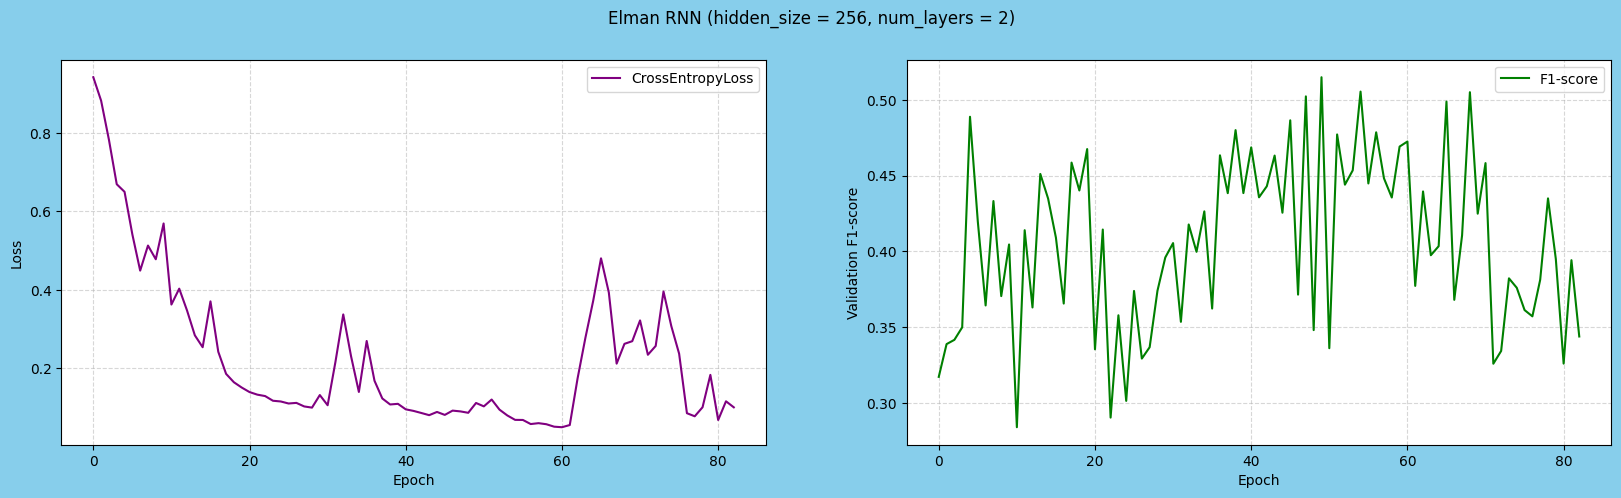

In [28]:
graph_figure = plt.figure(figsize=(20, 5), facecolor='skyblue')
graph_figure.suptitle("Elman RNN (hidden_size = 256, num_layers = 2)")
graph_ax1 = graph_figure.add_subplot(1, 2, 1)
graph_ax2 = graph_figure.add_subplot(1, 2, 2)
graph_ax1.grid(linestyle='--', alpha=0.5)
graph_ax1.set_xlabel("Epoch")
graph_ax1.set_ylabel("Loss")
graph_ax1.plot(result[0], label = 'CrossEntropyLoss', color='purple')
graph_ax1.legend()
graph_ax2.grid(linestyle='--', alpha=0.5)
graph_ax2.set_xlabel("Epoch")
graph_ax2.set_ylabel("Validation F1-score")
graph_ax2.plot(result[1], label = 'F1-score', color='green')
graph_ax2.legend()

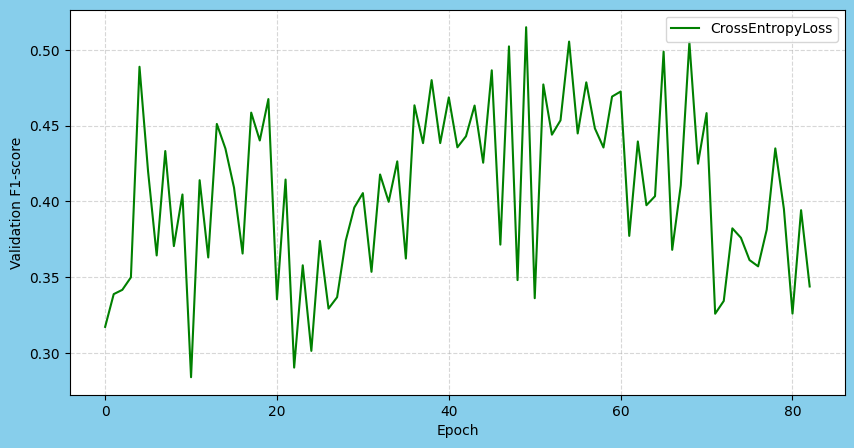

In [29]:
graph_figure = plt.figure(figsize=(10, 5), facecolor='skyblue')
graph_ax = graph_figure.add_subplot()
graph_ax.grid(linestyle='--', alpha=0.5)
graph_ax.set_xlabel("Epoch")
graph_ax.set_ylabel("Validation F1-score")
graph_ax.plot(result[1], label = 'CrossEntropyLoss', color='green')
graph_ax.legend()

### LSTM (num_layers = 1, hidden_size = 256)

In [38]:
@dataclass(frozen=True)
class TrainConfig:
    BATCH_SIZE: int = 6
    LR: float = 0.001
    BETAS: Tuple =  (0.9, 0.98)
    BIDIRECTIONAL: bool = False
train_config = TrainConfig()

In [40]:
class NERModelLSTM(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int,
                 embedding_model: AutoTokenizer, num_layers: int = 2, num_tags: int = 3):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier = nn.Linear(hidden_dim, num_tags)
        self.rnn = nn.LSTM(input_size = input_dim, hidden_size = hidden_dim,
                           num_layers = num_layers, bidirectional = False, batch_first = False)

    def forward(self, x: torch.tensor) -> torch.tensor:
        """x is tensor of shape BxS where B is batch size and S is sequence length of inputs"""
        with torch.no_grad():
            emb_x = self.embedding_model(x).last_hidden_state
        emb_x = torch.permute(emb_x, (1, 0, 2)) 
        out, _ = self.rnn(emb_x)
        out = torch.permute(out, (1, 0, 2))
        y = self.classifier(out) # B x S x E
        return y

In [44]:
ner_model = NERModelLSTM(input_dim = 1024, hidden_dim = 256, 
                         num_layers = 1, embedding_model = EMBD_MODEL).to(device='cuda')

In [45]:
optimizer = torch.optim.Adam(ner_model.parameters(), lr=train_config.LR, betas=train_config.BETAS)
criterion = nn.CrossEntropyLoss()

In [46]:
result = train_model(model = ner_model,
                     train_loader = train_loader,
                     val_loader = test_loader,
                     optimizer = optimizer,
                     criterion = criterion,
                     epochs = 1_000,
                     device = "cuda",
                     save_path="C:\\main\\GitHub\\documentReviewSystem\\NERTraining\\models",
                     name="LSTM_LAYERS_2_HIDDEN_256")

Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


Epoch 1 | Train Loss: 1.0001 | Val f1-score: 0.2776753714780071


Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


Epoch 2 | Train Loss: 0.8084 | Val f1-score: 0.2048088565992043


Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


...

Epoch 98 | Train Loss: 0.0064 | Val f1-score: 0.5210334166958728


Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


Epoch 99 | Train Loss: 0.0059 | Val f1-score: 0.40562292240303854


Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.11s/it]

Epoch 100 | Train Loss: 0.0053 | Val f1-score: 0.5153580225611181


### GRU (input_size = 1024, num_layers = 1, hidden_size = 512)

In [48]:
@dataclass(frozen=True)
class TrainConfig:
    BATCH_SIZE: int = 6
    LR: float = 0.001
    BETAS: Tuple =  (0.9, 0.98)
    BIDIRECTIONAL: bool = False
train_config = TrainConfig()

In [49]:
class NERModelGRU(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int,
                 embedding_model: AutoTokenizer, num_layers: int = 2, num_tags: int = 3):
        super().__init__()
        self.embedding_model = embedding_model
        self.classifier = nn.Linear(hidden_dim, num_tags)
        self.rnn = nn.GRU(input_size = input_dim, hidden_size = hidden_dim,
                           num_layers = num_layers, bidirectional = False, batch_first = False)

    def forward(self, x: torch.tensor) -> torch.tensor:
        """x is tensor of shape BxS where B is batch size and S is sequence length of inputs"""
        with torch.no_grad():
            emb_x = self.embedding_model(x).last_hidden_state
        emb_x = torch.permute(emb_x, (1, 0, 2))
        out, _ = self.rnn(emb_x)
        out = torch.permute(out, (1, 0, 2))
        y = self.classifier(out) # B x S x E
        return y

In [50]:
ner_model = NERModelGRU(input_dim = 1024, hidden_dim = 256, num_layers = 1, embedding_model = EMBD_MODEL).to(device='cuda')

In [51]:
optimizer = torch.optim.Adam(ner_model.parameters(), lr=train_config.LR, betas=train_config.BETAS)
criterion = nn.CrossEntropyLoss()

In [54]:
result = train_model(model = ner_model,
                     train_loader = train_loader,
                     val_loader = test_loader,
                     optimizer = optimizer,
                     criterion = criterion,
                     epochs = 1_000,
                     device = "cuda",
                     save_path="C:\\main\\GitHub\\documentReviewSystem\\NERTraining\\models",
                     name="GRU_LAYERS_2_HIDDEN_256")

Going through validation loader ..: 100%|██████████| 5/5 [01:51<00:00, 22.26s/it]


Epoch 1 | Train Loss: 0.9454 | Val f1-score: 0.3298734122593026


Going through validation loader ..: 100%|██████████| 5/5 [01:52<00:00, 22.42s/it]


Epoch 2 | Train Loss: 0.7577 | Val f1-score: 0.2637833805442503


Going through validation loader ..: 100%|██████████| 5/5 [01:51<00:00, 22.27s/it]


...

Going through validation loader ..: 100%|██████████| 5/5 [01:47<00:00, 21.59s/it]


Epoch 73 | Train Loss: 0.3947 | Val f1-score: 0.41329661852558824


Going through validation loader ..: 100%|██████████| 5/5 [01:47<00:00, 21.60s/it]


Epoch 74 | Train Loss: 0.1256 | Val f1-score: 0.414779999980965


Going through validation loader ..:   0%|          | 0/5 [00:26<?, ?it/s]


### BERT MODEL (hidden_size = 1024, num_hidden_layers = 2, num_attention_head = 4)

In [11]:
@dataclass(frozen=True)
class TrainConfig:
    BATCH_SIZE: int = 6
    LR: float = 1e-5
    BETAS: Tuple =  (0.9, 0.98)
    BIDIRECTIONAL: bool = False
train_config = TrainConfig()

In [12]:
class NERModelBERT(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int,
                 embedding_model: AutoTokenizer, num_layers: int = 2, num_tags: int = 3):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.embedding_model = embedding_model
        self.classifier = nn.Linear(input_dim, num_tags)
        self.rnn = BertModel(self.config).encoder

    @property
    def config(self):
        config = BertConfig(
            vocab_size=len(TOKENIZER.get_vocab()),
            hidden_size=self.input_dim,
            intermediate_size = self.hidden_dim,
            num_hidden_layers=1,
            num_attention_heads=4)
        return config

    def forward(self, x: torch.tensor) -> torch.tensor:
        """x is tensor of shape BxS where B is batch size and S is sequence length of inputs"""
        with torch.no_grad():
            emb_x = self.embedding_model(x).last_hidden_state
        emb_x = torch.permute(emb_x, (1, 0, 2))
        last_hidden_state = self.rnn(emb_x).last_hidden_state
        last_hidden_state = torch.permute(last_hidden_state, (1, 0, 2))
        y = self.classifier(last_hidden_state) # B x S x E
        return y

In [21]:
ner_model = NERModelBERT(input_dim = 1024, hidden_dim = 256, 
                         num_layers = 2, embedding_model = EMBD_MODEL).to(device='cuda')

In [ ]:
# LOADED EPOCH: 450 + 278 + 192 + 290
ner_model.rnn.load_state_dict(torch.load("C:\\main\\GitHub\\documentReviewSystem\\NERTraining\\models\\BERT_MODEL_epoch#292.pth"))

<All keys matched successfully>

In [40]:
optimizer = torch.optim.Adam(ner_model.parameters(), lr=train_config.LR, betas=train_config.BETAS)
criterion = nn.CrossEntropyLoss()
optimizer.load_state_dict(torch.load("C:\\main\\GitHub\\documentReviewSystem\\NERTraining\\models\\OPTIMIZER_BERT_MODEL_epoch#292.pth"))

In [41]:
result = train_model(model = ner_model,
                     train_loader = train_loader,
                     val_loader = test_loader,
                     optimizer = optimizer,
                     criterion = criterion,
                     epochs = 1_000,
                     device = "cuda",
                     save_path= "C:\\main\\GitHub\\documentReviewSystem\\NERTraining\\models",
                     name= "BERT_MODEL")

Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


Epoch 1 | Train Loss: 0.0590 | Val f1-score: 0.4833583336179719


Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.13s/it]


Epoch 2 | Train Loss: 0.0565 | Val f1-score: 0.4888121770049863


Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.13s/it]


...

Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


Epoch 64 | Train Loss: 0.0460 | Val f1-score: 0.5034838371975064


Going through validation loader ..: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


Epoch 65 | Train Loss: 0.0494 | Val f1-score: 0.5077963434459715


Going through loader ...:  14%|█▍        | 1/7 [00:04<00:26,  4.43s/it]
